In [2]:
# Install Libraries
!pip install pandas scikit-learn matplotlib seaborn

In [3]:

# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler



In [4]:
#Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving credit_dataset.csv to credit_dataset.csv


In [5]:
#Load Dataset
df = pd.read_csv("credit_dataset.csv")
display(df.head())

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000,Master's Degree,Married,2,Owned,High
2,35,Female,75000,Doctorate,Married,1,Owned,High
3,40,Male,125000,High School Diploma,Single,0,Owned,High
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,High


In [6]:
#Handle Missing Values
df = df.dropna()

In [7]:
#Convert Categorical Data
df = pd.get_dummies(df)

In [8]:
# Target
y = df['Credit Score_High']

# Features
X = df.drop(columns=[col for col in df.columns if 'Credit Score_' in col])

In [9]:


# Split Dataset (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# ---------------- Logistic Regression (with scaling + solver fix)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(solver='saga', max_iter=10000)  # solver + higher iterations
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)



In [11]:
# ---------------- Decision Tree (no scaling needed)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)



In [12]:
# ---------------- Random Forest (no scaling needed)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)



In [13]:
#Model Accuracy Comparison
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Logistic Regression Accuracy: 0.9696969696969697
Decision Tree Accuracy: 0.9393939393939394
Random Forest Accuracy: 0.9393939393939394


In [14]:
# ===============================
# 📊 Evaluation Function
# ===============================
def evaluate_model(y_test, y_pred, model_name):
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    return {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc
    }

# Evaluate all models
results = []

results.append(evaluate_model(y_test, pred_lr, "Logistic Regression"))
results.append(evaluate_model(y_test, pred_dt, "Decision Tree"))
results.append(evaluate_model(y_test, pred_rf, "Random Forest"))

# Convert to DataFrame
results_df = pd.DataFrame(results)

print("\n📊 Model Comparison:")
print(results_df)


📊 Model Comparison:
                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.958333  1.000000  0.978723  0.950000
1        Decision Tree   1.000000  0.913043  0.954545  0.956522
2        Random Forest   0.956522  0.956522  0.956522  0.928261


In [15]:
# ===============================
# 🏆 Best Model Selection
# ===============================
best_model_name = results_df.loc[results_df["F1 Score"].idxmax(), "Model"]

print("\n🏆 Best Model:", best_model_name)

# Assign best model
if best_model_name == "Logistic Regression":
    best_model = lr
    X_test_used = X_test_scaled
elif best_model_name == "Decision Tree":
    best_model = dt
    X_test_used = X_test
else:
    best_model = rf
    X_test_used = X_test


🏆 Best Model: Logistic Regression


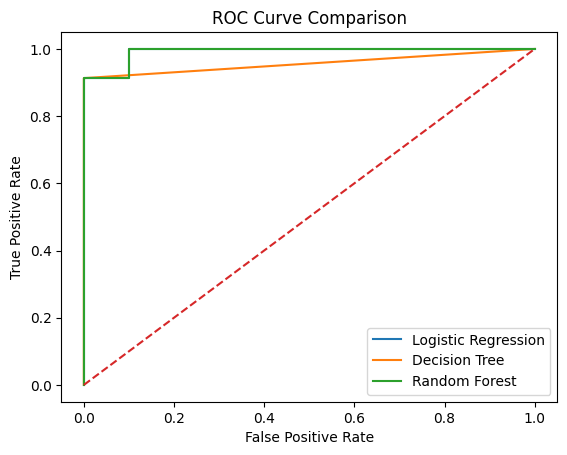

In [19]:
from sklearn.metrics import roc_curve

plt.figure()

# Logistic Regression
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

# Decision Tree
dt_probs = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

# Random Forest
rf_probs = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# Random line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

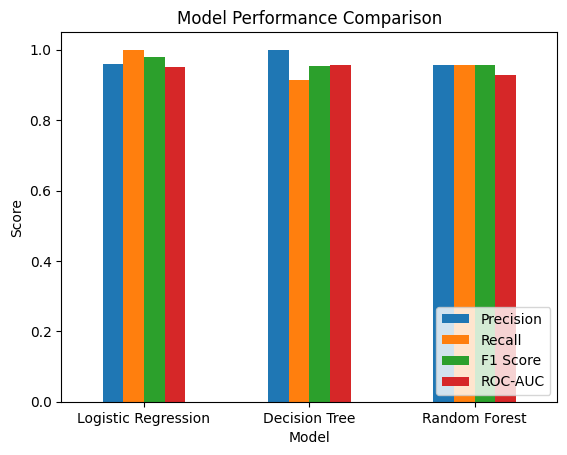

In [20]:
results_df.set_index("Model")[["Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

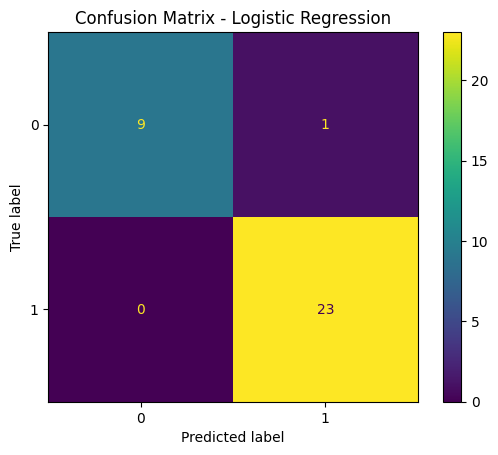

In [16]:
#Confusion Matrix Visualization
from sklearn.metrics import ConfusionMatrixDisplay

if best_model_name == "Logistic Regression":
    y_pred_best = lr.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [28]:
import pickle

# Save best model
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler (important for Logistic Regression)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save model name
with open("model_name.pkl", "wb") as f:
    pickle.dump(best_model_name, f)

# Save column names (VERY IMPORTANT for input alignment)
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("✅ All files saved successfully!")

✅ All files saved successfully!


In [33]:
from google.colab import files

files.download("best_model.pkl")
files.download("scaler.pkl")
files.download("model_name.pkl")
files.download("columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
%%writefile credit_app.py
import streamlit as st
import pandas as pd
import pickle

st.title("💳 Credit Score Prediction App")



# Load saved files
best_model = pickle.load(open("best_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
model_name = pickle.load(open("model_name.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

st.subheader("Enter Customer Details")

age = st.number_input("Age", 18, 100)
income = st.number_input("Income")
children = st.number_input("Number of Children", 0, 10)

gender = st.selectbox("Gender", ["Male", "Female"])
education = st.selectbox("Education", ["High School", "Bachelors", "Masters", "PhD"])
marital = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])
home = st.selectbox("Home Ownership", ["Owned", "Rented"])

if st.button("Predict"):

    user_dict = {
        "Age": age,
        "Income": income,
        "Number of Children": children,
        "Gender_Male": 1 if gender == "Male" else 0,
        "Gender_Female": 1 if gender == "Female" else 0,
        "Education_High School": 1 if education == "High School" else 0,
        "Education_Bachelors": 1 if education == "Bachelors" else 0,
        "Education_Masters": 1 if education == "Masters" else 0,
        "Education_PhD": 1 if education == "PhD" else 0,
        "Marital Status_Single": 1 if marital == "Single" else 0,
        "Marital Status_Married": 1 if marital == "Married" else 0,
        "Marital Status_Divorced": 1 if marital == "Divorced" else 0,
        "Home Ownership_Owned": 1 if home == "Owned" else 0,
        "Home Ownership_Rented": 1 if home == "Rented" else 0,
    }

    user_df = pd.DataFrame([user_dict])
    user_df = user_df.reindex(columns=columns, fill_value=0)

    if model_name == "Logistic Regression":
        user_df = scaler.transform(user_df)

    prediction = best_model.predict(user_df)

    if prediction[0] == 1:
        st.success(f"{model_name}: Creditworthy Customer ✅")
    else:
        st.error(f"{model_name}: Risky Customer ⚠️")

Writing credit_app.py


In [35]:
import pickle

pickle.dump(best_model, open("best_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(best_model_name, open("model_name.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

In [36]:
!pip install streamlit pyngrok

In [40]:
from pyngrok import ngrok

# IMPORTANT: Replace 'YOUR_NGROK_TOKEN_HERE' with your actual ngrok authentication token.
# You can get your authtoken from your ngrok dashboard: https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_AUTH_TOKEN = "YOUR_NGROK_TOKEN_HERE" # <--- PASTE YOUR TOKEN HERE!
!ngrok config add-authtoken {NGROK_AUTH_TOKEN}

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [45]:
!ngrok config add-authtoken 3BfZUQQ9uFKRdwA980ZXYGjJLbx_5dCrmmwQTj2rHFbB59Uyt

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [46]:
!streamlit run credit_app.py &>/dev/null &

In [47]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://unended-cellulous-beryl.ngrok-free.dev" -> "http://localhost:8501">

In [25]:
age = int(input("Enter Age: "))
income = float(input("Enter Income: "))
children = int(input("Number of Children: "))

gender = input("Gender (Male/Female): ")
education = input("Education (High School/Bachelors/Masters/PhD): ")
marital = input("Marital Status (Single/Married/Divorced): ")
home = input("Home Ownership (Owned/Rented): ")

user_dict = {
    "Age": age,
    "Income": income,
    "Number of Children": children,
    "Gender_Male": 1 if gender == "Male" else 0,
    "Gender_Female": 1 if gender == "Female" else 0,
    "Education_High School": 1 if education == "High School" else 0,
    "Education_Bachelors": 1 if education == "Bachelors" else 0,
    "Education_Masters": 1 if education == "Masters" else 0,
    "Education_PhD": 1 if education == "PhD" else 0,
    "Marital Status_Single": 1 if marital == "Single" else 0,
    "Marital Status_Married": 1 if marital == "Married" else 0,
    "Marital Status_Divorced": 1 if marital == "Divorced" else 0,
    "Home Ownership_Owned": 1 if home == "Owned" else 0,
    "Home Ownership_Rented": 1 if home == "Rented" else 0,
}

user_data = pd.DataFrame([user_dict])
user_data = user_data.reindex(columns=X.columns, fill_value=0)

if best_model_name == "Logistic Regression":
    user_data = scaler.transform(user_data)

prediction = best_model.predict(user_data)

if prediction[0] == 1:
    print(f"{best_model_name}: Customer is Creditworthy")
else:
    print(f"{best_model_name}: Customer is Risky")

Enter Age: 23
Enter Income: 450000
Number of Children: 5
Gender (Male/Female): male
Education (High School/Bachelors/Masters/PhD): high school
Marital Status (Single/Married/Divorced): single
Home Ownership (Owned/Rented): owned
Logistic Regression: Customer is Creditworthy
